# Data Mining Project Code

## Libraries

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## Constants & Configuration

In [2]:
# File path
FILE_JAN_2014 = './csvs/jan_2014.csv'

# Elo bracket definitions (name, lower_bound, upper_bound)
ELO_BRACKETS = [
    ("World Champion",       2800,  np.inf),
    ("Super Grandmaster",    2700,  2799),
    ("Grandmaster (GM)",     2500,  2699),
    ("International Master (IM)", 2400, 2499),
    ("FIDE Master (FM)",     2300,  2399),
    ("National Master",      2200,  2299),
    ("Expert",               2000,  2199),
    ("Class A",              1800,  1999),
    ("Class B",              1600,  1799),
    ("Class C",              1400,  1599),
    ("Class D",              1200,  1399),
    ("Beginner",             -np.inf, 1199),
]

# Preferred order for plots / pivot tables
TITLE_ORDER = [
    "Beginner","Class D","Class C","Class B","Class A",
    "Expert","National Master","FIDE Master (FM)",
    "International Master (IM)","Grandmaster (GM)",
    "Super Grandmaster","World Champion"
]

## Utility Functions

In [3]:
def extract_elo_rating(raw_val):
    """Parse an Elo-like string and return an integer rating or NaN.
    Examples: '2450', '2450?', 'unrated' -> 2450 / NaN.
    """
    if pd.isna(raw_val):
        return np.nan
    s = str(raw_val).strip()
    m = re.search(r'(\d{3,4})', s)
    return int(m.group(1)) if m else np.nan


def map_elo_to_bracket(elo_value, brackets=ELO_BRACKETS):
    """Map a numeric Elo to its bracket name. Returns None for NaN."""
    if np.isnan(elo_value):
        return None
    for name, low, high in brackets:
        if low <= elo_value <= high:
            return name
    return None


def normalize_game_result(raw_result):
    """Normalize PGN style 'Result' into one of {'white','black','draw','other'}."""
    if pd.isna(raw_result):
        return 'other'
    t = str(raw_result).strip().replace(" ", "")
    if t in ("1-0", "1/0"):
        return 'white'
    if t in ("0-1", "0/1"):
        return 'black'
    if t in ("1/2-1/2", "1/2"):
        return 'draw'
    return 'other'

## Data Loading & Initial Preparation

In [4]:
def load_and_filter_games(filepath):
    """Load CSV with some dtype hints and filter out tournament lines."""
    df = pd.read_csv(
        filepath,
        dtype={
            'GameID': 'int64',
            'WhiteElo': 'float64',
            'BlackElo': 'float64'
        },
        na_values=['?', 'unrated', 'None', '']
    )
    # remove rows where Event contains 'tournament'
    df = df[~df['Event'].str.contains('tournament', na=False)].copy()
    return df


def enrich_with_elo_and_brackets(df):
    """Add numeric ELO columns and bracket columns to the DataFrame in place."""
    if 'WhiteElo_num' not in df.columns:
        df['WhiteElo_num'] = df['WhiteElo'].apply(extract_elo_rating)
    if 'BlackElo_num' not in df.columns:
        df['BlackElo_num'] = df['BlackElo'].apply(extract_elo_rating)

    if 'White_bracket' not in df.columns:
        df['White_bracket'] = df['WhiteElo_num'].apply(map_elo_to_bracket)
    if 'Black_bracket' not in df.columns:
        df['Black_bracket'] = df['BlackElo_num'].apply(map_elo_to_bracket)

    # normalized result column
    if 'Result_norm' not in df.columns:
        df['Result_norm'] = df['Result'].apply(lambda s: (
            "1-0" if normalize_game_result(s) == 'white' else
            "0-1" if normalize_game_result(s) == 'black' else
            "1/2-1/2" if normalize_game_result(s) == 'draw' else
            "other"
        ))

## Title-vs-Title CSV Builder

In [5]:
def build_title_vs_title_report_csv(games_df, out_path):
    """
    Build an aggregated 'title vs title' report and write to CSV.
    Each row is one triple: (color, player_title, opponent_title) with stats:
      wins, losses, draws, total_games, win_pct, loss_pct, draw_pct, ratio,
      avg_plies, avg_turns
    Returns: result DataFrame
    """
    df = games_df.copy()
    enrich_with_elo_and_brackets(df)  # ensure bracket columns exist

    # defensive normalization of Result_norm
    def _norm_result_for_counts(s):
        if pd.isna(s): return "other"
        t = str(s).strip().replace(" ", "")
        if t in ("1-0", "1/0"): return "1-0"
        if t in ("0-1", "0/1"): return "0-1"
        if t in ("1/2-1/2", "1/2"): return "1/2-1/2"
        return "other"
    if 'Result_norm' not in df.columns:
        df['Result_norm'] = df['Result'].apply(_norm_result_for_counts)

    rows = []
    # iterate color perspective (white-centric then black-centric)
    for color in ('white', 'black'):
        for player_title in TITLE_ORDER:
            for opp_title in TITLE_ORDER:
                if color == 'white':
                    sel_mask = (df['White_bracket'] == player_title) & (df['Black_bracket'] == opp_title)
                    wins = (df.loc[sel_mask, 'Result_norm'] == '1-0').sum()
                    losses = (df.loc[sel_mask, 'Result_norm'] == '0-1').sum()
                    draws = (df.loc[sel_mask, 'Result_norm'] == '1/2-1/2').sum()
                    avg_plies = df.loc[sel_mask, 'Half Move Count'].mean() if sel_mask.any() else np.nan
                else:
                    sel_mask = (df['Black_bracket'] == player_title) & (df['White_bracket'] == opp_title)
                    wins = (df.loc[sel_mask, 'Result_norm'] == '0-1').sum()
                    losses = (df.loc[sel_mask, 'Result_norm'] == '1-0').sum()
                    draws = (df.loc[sel_mask, 'Result_norm'] == '1/2-1/2').sum()
                    avg_plies = df.loc[sel_mask, 'Half Move Count'].mean() if sel_mask.any() else np.nan

                total = int(wins + losses + draws)
                if total == 0:
                    win_pct = loss_pct = draw_pct = 0.0
                else:
                    win_pct = wins / total * 100.0
                    loss_pct = losses / total * 100.0
                    draw_pct = draws / total * 100.0

                ratio = np.nan
                if losses == 0 and wins == 0:
                    ratio = np.nan
                elif losses == 0:
                    ratio = np.inf
                else:
                    ratio = wins / losses

                avg_plies_val = float(avg_plies) if not pd.isna(avg_plies) else np.nan
                avg_turns_val = (avg_plies_val / 2.0) if not np.isnan(avg_plies_val) else np.nan

                rows.append({
                    'color': color,
                    'player_title': player_title,
                    'opponent_title': opp_title,
                    'wins': int(wins),
                    'losses': int(losses),
                    'draws': int(draws),
                    'total_games': total,
                    'win_pct': round(win_pct, 3),
                    'loss_pct': round(loss_pct, 3),
                    'draw_pct': round(draw_pct, 3),
                    'ratio': ratio,
                    'avg_plies': round(avg_plies_val, 3) if not np.isnan(avg_plies_val) else np.nan,
                    'avg_turns': round(avg_turns_val, 3) if not np.isnan(avg_turns_val) else np.nan
                })

    result_df = pd.DataFrame(rows)

    # sort order: color (white then black), player_title in TITLE_ORDER, opponent_title in TITLE_ORDER
    color_rank = {'white': 0, 'black': 1}
    result_df['color_rank'] = result_df['color'].map(color_rank)
    result_df['player_rank'] = result_df['player_title'].map({t: i for i, t in enumerate(TITLE_ORDER)})
    result_df['opp_rank'] = result_df['opponent_title'].map({t: i for i, t in enumerate(TITLE_ORDER)})

    result_df = result_df.sort_values(['color_rank', 'player_rank', 'opp_rank']).drop(
        columns=['color_rank', 'player_rank', 'opp_rank']
    ).reset_index(drop=True)

    # write CSV
    result_df.to_csv(out_path, index=False, encoding='utf-8')
    print(f"Wrote title-vs-title CSV: {out_path} ({len(result_df)} rows)")
    return result_df

## Visualization Functions

In [6]:
def _build_label_map_from_counts(df_report, order=TITLE_ORDER):
    """Helper: returns a dict mapping title -> 'Title\n(count)' using total_games (white fallback)."""
    games_count = df_report[df_report['color'] == 'white'].groupby('player_title', observed=False)['total_games'].sum().reindex(order).fillna(0).astype(int)
    if games_count.sum() == 0:
        games_count = df_report.groupby('player_title')['total_games'].sum().reindex(order).fillna(0).astype(int)
    # format with thousands separators
    label_map = {t: f"{t}\n({games_count.get(t,0):,})" for t in order}
    return label_map


def plot_win_pct_heatmaps(df_report, order=TITLE_ORDER, min_games=1):
    """Annotated heatmaps of win percentage for color perspectives (white, black)."""
    cat_type = pd.CategoricalDtype(categories=order, ordered=True)
    df_report['player_title'] = df_report['player_title'].astype(cat_type)
    df_report['opponent_title'] = df_report['opponent_title'].astype(cat_type)

    label_map = _build_label_map_from_counts(df_report, order)

    for color in ['white', 'black']:
        sub = df_report[df_report['color'] == color]
        mat = sub.pivot(index='player_title', columns='opponent_title', values='win_pct').reindex(index=order, columns=order)
        counts = sub.pivot(index='player_title', columns='opponent_title', values='total_games').reindex(index=order, columns=order)
        mask = counts.isna() | (counts < min_games)
        annot = mat.round(1).astype(object).where(~mask, "")

        plt.figure(figsize=(12, 10))
        ax = sns.heatmap(mat, annot=annot, fmt="", linewidths=.5, cmap="viridis", mask=mask, cbar_kws={'label':'Win %'})
        plt.title(f"{color.capitalize()} win % (masked: < {min_games} games)")
        plt.ylabel("Player title")
        plt.xlabel("Opponent title")
        ax.set_xticks(np.arange(len(order)) + 0.5)
        ax.set_yticks(np.arange(len(order)) + 0.5)
        ax.set_xticklabels([label_map[t] for t in order], rotation=45, ha='center')
        ax.set_yticklabels([label_map[t] for t in order], rotation=0, va='center')
        plt.tight_layout()
        plt.show()


def plot_draw_pct_heatmaps(df_report, order=TITLE_ORDER, min_games=1):
    """Annotated heatmaps for draw percentage (same style as win_pct)."""
    cat_type = pd.CategoricalDtype(categories=order, ordered=True)
    df_report['player_title'] = df_report['player_title'].astype(cat_type)
    df_report['opponent_title'] = df_report['opponent_title'].astype(cat_type)

    label_map = _build_label_map_from_counts(df_report, order)

    if 'draw_pct' not in df_report.columns:
        if {'draws', 'total_games'}.issubset(df_report.columns):
            df_report['draw_pct'] = (df_report['draws'] / df_report['total_games'].replace(0, np.nan)) * 100.0
        else:
            raise ValueError("df_report must contain 'draw_pct' or both 'draws' and 'total_games'")

    for color in ['white', 'black']:
        sub = df_report[df_report['color'] == color]
        mat = sub.pivot(index='player_title', columns='opponent_title', values='draw_pct').reindex(index=order, columns=order)
        counts = sub.pivot(index='player_title', columns='opponent_title', values='total_games').reindex(index=order, columns=order)
        mask = counts.isna() | (counts < min_games)
        annot = mat.round(1).astype(object).where(~mask, "")

        plt.figure(figsize=(12, 10))
        ax = sns.heatmap(mat, annot=annot, fmt="", linewidths=.5, cmap="viridis", mask=mask, cbar_kws={'label':'Draw %'})
        plt.title(f"{color.capitalize()} draw % (masked: < {min_games} games)")
        plt.ylabel("Player title")
        plt.xlabel("Opponent title")
        ax.set_xticks(np.arange(len(order)) + 0.5)
        ax.set_yticks(np.arange(len(order)) + 0.5)
        ax.set_xticklabels([label_map[t] for t in order], rotation=45, ha='center')
        ax.set_yticklabels([label_map[t] for t in order], rotation=0, va='center')
        plt.tight_layout()
        plt.show()


def plot_avg_turns_heatmap(df_report, order=TITLE_ORDER, min_games=1):
    """Annotated heatmap for average number of TURNS per matchup (avg_turns)."""
    cat_type = pd.CategoricalDtype(categories=order, ordered=True)
    df_report['player_title'] = df_report['player_title'].astype(cat_type)
    df_report['opponent_title'] = df_report['opponent_title'].astype(cat_type)

    label_map = _build_label_map_from_counts(df_report, order)

    if 'avg_turns' not in df_report.columns:
        if 'avg_plies' in df_report.columns:
            df_report['avg_turns'] = df_report['avg_plies'] / 2.0
        else:
            raise ValueError("df_report must contain 'avg_turns' or 'avg_plies'")

    for color in ['white', 'black']:
        sub = df_report[df_report['color'] == color]
        mat = sub.pivot(index='player_title', columns='opponent_title', values='avg_turns').reindex(index=order, columns=order)
        counts = sub.pivot(index='player_title', columns='opponent_title', values='total_games').reindex(index=order, columns=order)
        mask = counts.isna() | (counts < min_games)
        annot = mat.round(2).astype(object).where(~mask, "")

        plt.figure(figsize=(12, 10))
        ax = sns.heatmap(mat, annot=annot, fmt="", linewidths=.5, cmap="RdBu", mask=mask, cbar_kws={'label':'Avg turns'})
        plt.title(f"{color.capitalize()} average turns (masked: < {min_games} games)")
        plt.ylabel("Player title")
        plt.xlabel("Opponent title")
        ax.set_xticks(np.arange(len(order)) + 0.5)
        ax.set_yticks(np.arange(len(order)) + 0.5)
        ax.set_xticklabels([label_map[t] for t in order], rotation=45, ha='center')
        ax.set_yticklabels([label_map[t] for t in order], rotation=0, va='center')
        plt.tight_layout()
        plt.show()

## Features and Decision Tree

In [7]:
def prepare_model_features(games_df, eco_top_n=50, fill_elo_strategy='median'):
    """
    Prepare modeling dataset (X, y).
    X: numeric Elo features and one-hot for top ECOs (others grouped as 'OTHER')
    y: outcome labels ('white','black','draw')
    """
    df = games_df.copy()
    df['WhiteElo_num'] = df['WhiteElo'].apply(extract_elo_rating)
    df['BlackElo_num'] = df['BlackElo'].apply(extract_elo_rating)

    df['outcome'] = df['Result'].apply(normalize_game_result)
    df = df[df['outcome'].isin(['white', 'black', 'draw'])].copy()

    if fill_elo_strategy == 'median':
        we_m = int(np.nanmedian(df['WhiteElo_num']))
        be_m = int(np.nanmedian(df['BlackElo_num']))
    else:
        we_m = be_m = fill_elo_strategy

    df['WhiteElo_num'] = df['WhiteElo_num'].fillna(we_m)
    df['BlackElo_num'] = df['BlackElo_num'].fillna(be_m)

    df['elo_diff'] = df['WhiteElo_num'] - df['BlackElo_num']
    df['elo_mean'] = (df['WhiteElo_num'] + df['BlackElo_num']) / 2.0

    # ECO grouping (top N one-hot, rest = OTHER)
    top_ecos = df['ECO'].value_counts().nlargest(eco_top_n).index.tolist()
    df['ECO_group'] = df['ECO'].where(df['ECO'].isin(top_ecos), other='OTHER')
    eco_dummies = pd.get_dummies(df['ECO_group'], prefix='ECO')

    X = pd.concat([
        df[['WhiteElo_num', 'BlackElo_num', 'elo_diff', 'elo_mean']].reset_index(drop=True),
        eco_dummies.reset_index(drop=True)
    ], axis=1)
    y = df['outcome'].reset_index(drop=True)
    return X, y


def train_and_evaluate_decision_tree(games_df, eco_top_n=50, random_state=42, test_size=0.2, max_depth=None, class_weight='balanced'):
    """
    Prepare features, split, train a DecisionTreeClassifier, and print evaluation metrics.
    Returns: trained clf, (X_test, y_test), y_pred
    """
    X, y = prepare_model_features(games_df, eco_top_n=eco_top_n)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    clf = DecisionTreeClassifier(random_state=random_state, max_depth=max_depth, class_weight=class_weight)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification report:\n", classification_report(y_test, y_pred, digits=4))
    print("\nConfusion matrix (rows=true, cols=pred):\n", confusion_matrix(y_test, y_pred))

    fi = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
    print("\nTop feature importances:\n", fi.head(20).to_string())

    return clf, X_test, y_test, y_pred

## Chi-Square with Standardized Residuals

In [8]:
def chi_square_opening_vs_bracket(games_df, bracket_col='White_bracket', eco_col='ECO', top_n=25, inspect_bracket='Class D', inspect_eco='C20', expected_thresh=5):
    """
    Perform chi-square on a contingency table of bracket vs ECO (top N ECOs).
    Prints top standardized residuals (over/under represented) and displays a heatmap.
    Returns a dict with observed, expected, and residual DataFrames.
    """
    df2 = games_df.dropna(subset=[bracket_col, eco_col]).copy()
    top_ecos = df2[eco_col].value_counts().nlargest(top_n).index
    ct = pd.crosstab(df2[bracket_col], df2[eco_col]).reindex(index=TITLE_ORDER).fillna(0)[top_ecos]

    # drop empty rows and columns
    ct = ct.loc[ct.sum(axis=1) > 0, ct.columns[ct.sum(axis=0) > 0]]

    if ct.shape[0] < 2 or ct.shape[1] < 2:
        raise ValueError("Not enough non-empty rows/cols to run chi-square. Adjust top_n or aggregate.")

    chi2, p, dof, expected = chi2_contingency(ct)
    obs = ct
    exp = pd.DataFrame(expected, index=obs.index, columns=obs.columns)
    std_resid = (obs - exp) / np.sqrt(exp)

    flat = std_resid.stack().reset_index()
    flat.columns = ['bracket', 'eco', 'std_resid']
    flat['abs_resid'] = flat['std_resid'].abs()

    top_over = flat.sort_values('std_resid', ascending=False).head(20)
    top_under = flat.sort_values('std_resid').head(20)

    print("Top over-represented (bracket, ECO, std_resid):")
    print(top_over[['bracket', 'eco', 'std_resid']].to_string(index=False))
    print("\nTop under-represented (bracket, ECO, std_resid):")
    print(top_under[['bracket', 'eco', 'std_resid']].to_string(index=False))

    # heatmap mask small expected cells
    mask = exp < expected_thresh
    plt.figure(figsize=(14, 8))
    ax = sns.heatmap(std_resid, cmap='RdBu', center=0, annot=std_resid.round(1), fmt=".1f", mask=mask, linewidths=0.5, cbar_kws={'label': 'Std residual'})
    ax.set_title(f"Standardized residuals (masked: expected < {expected_thresh})")
    ax.set_ylabel("Elo bracket")
    ax.set_xlabel("ECO code")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # optional drill-down for a particular cell
    if (inspect_bracket in ct.index) and (inspect_eco in ct.columns):
        O = int(ct.loc[inspect_bracket, inspect_eco])
        E = float(exp.loc[inspect_bracket, inspect_eco])
        std_val = (O - E) / np.sqrt(E) if E > 0 else np.nan
        row_total = int(ct.loc[inspect_bracket].sum())
        col_total = int(ct[inspect_eco].sum())
        n_total = int(ct.values.sum())

        pct_in_bracket = O / row_total * 100.0 if row_total > 0 else np.nan
        overall_pct = col_total / n_total * 100.0 if n_total > 0 else np.nan
        enrichment = (pct_in_bracket / overall_pct) if overall_pct > 0 else np.nan

        print(f"\nDrill-down: {inspect_bracket} × {inspect_eco}")
        print(f"Observed O = {O}, Expected E = {E:.1f}, std_resid = {std_val:.2f}")
        print(f"Row total = {row_total}, Column total = {col_total}, N = {n_total}")
        print(f"pct_in_bracket = {pct_in_bracket:.2f}%, overall_pct = {overall_pct:.2f}%, enrichment = {enrichment:.2f}")

    return {
        'chi2': chi2,
        'pvalue': p,
        'dof': dof,
        'observed': obs,
        'expected': exp,
        'std_resid': std_resid,
        'top_over': top_over,
        'top_under': top_under
    }

## Main Execution

Loaded Jan 2014 games:
<class 'pandas.core.frame.DataFrame'>
Index: 681823 entries, 0 to 697599
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   GameID           681823 non-null  int64  
 1   Event            681823 non-null  object 
 2   White            681764 non-null  object 
 3   Black            681771 non-null  object 
 4   Result           681823 non-null  object 
 5   Date             681823 non-null  object 
 6   Time             681823 non-null  object 
 7   WhiteElo         681764 non-null  float64
 8   BlackElo         681771 non-null  float64
 9   ECO              681712 non-null  object 
 10  Opening          681712 non-null  object 
 11  TimeControl      681823 non-null  object 
 12  Termination      681823 non-null  object 
 13  Half Move Count  681823 non-null  int64  
dtypes: float64(2), int64(2), object(10)
memory usage: 78.0+ MB
Wrote title-vs-title CSV: ./title_vs_title_report_jan20

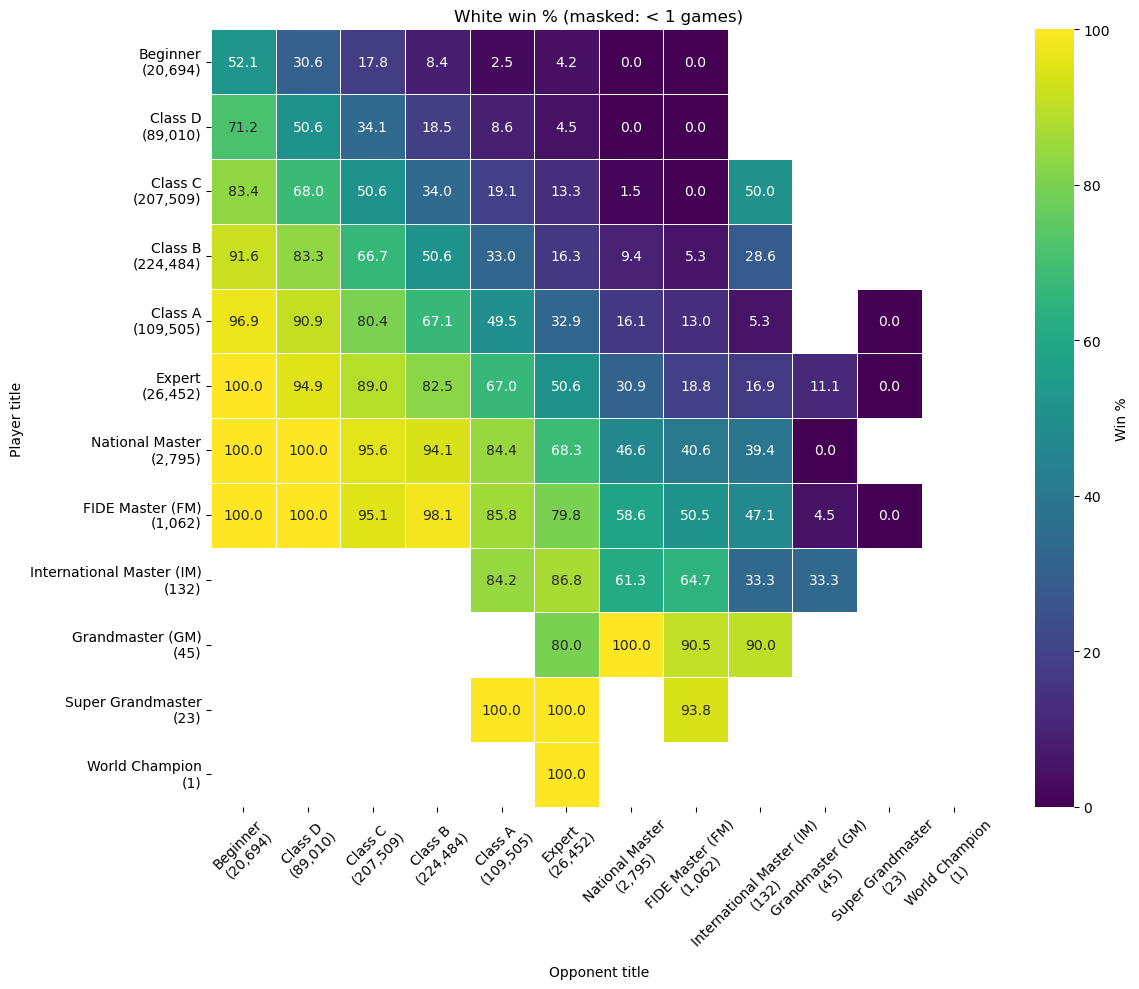

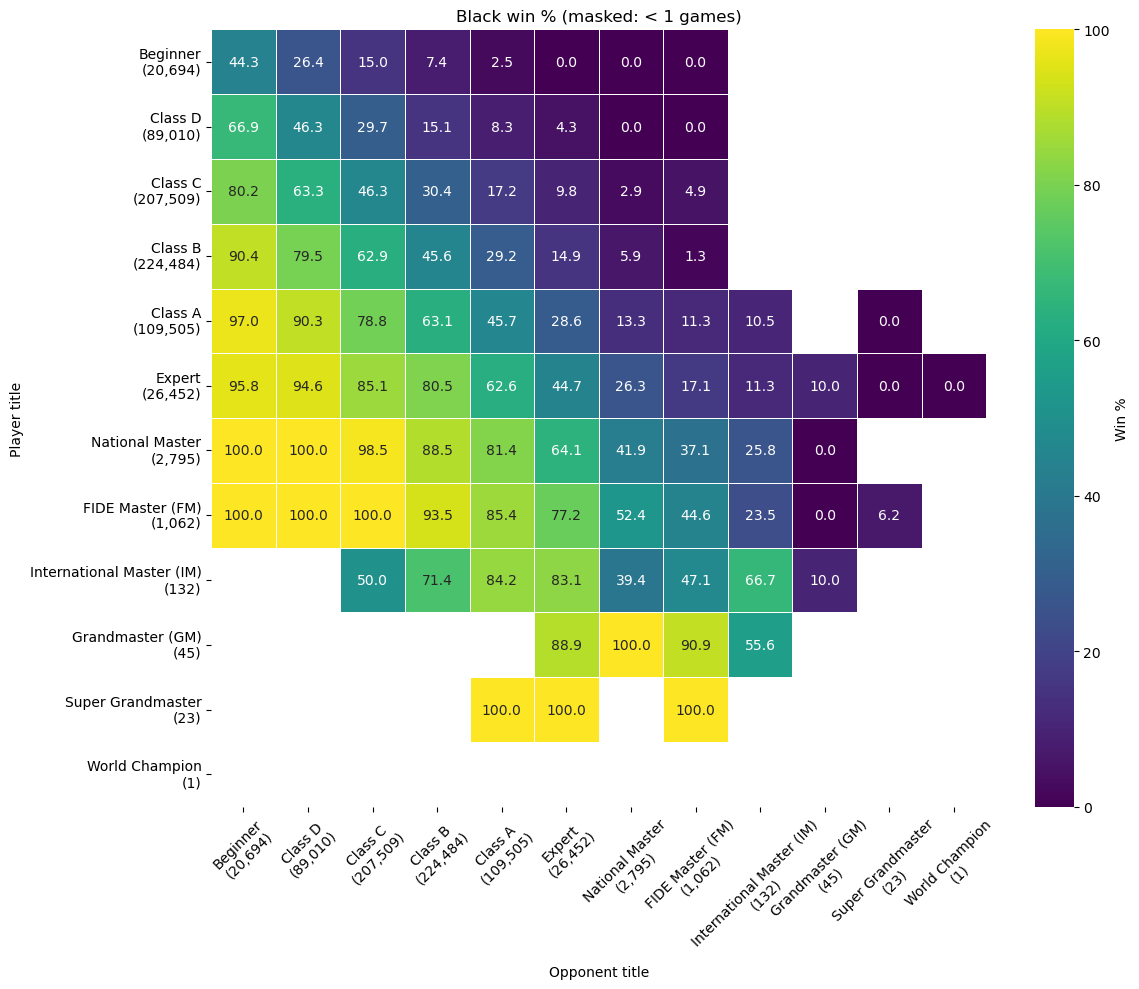

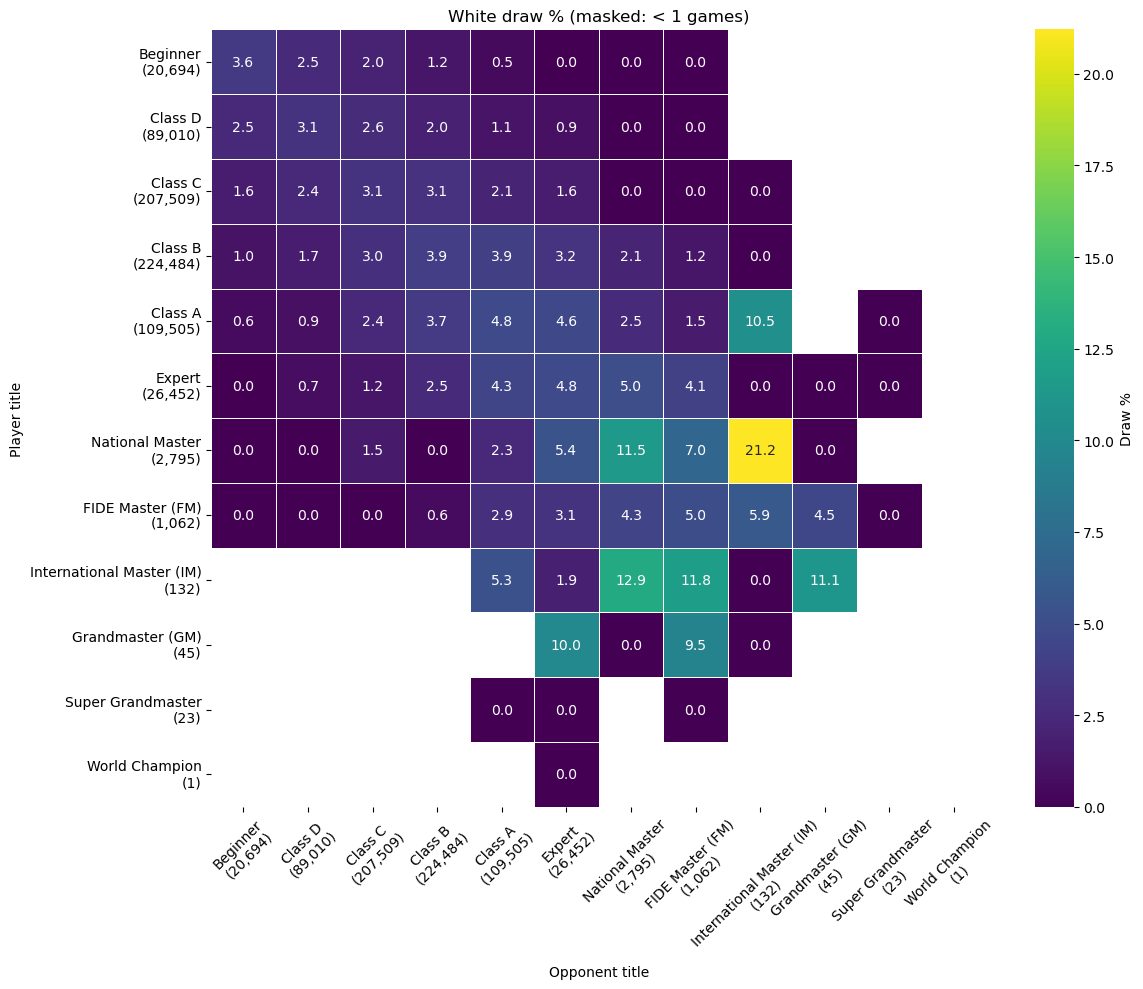

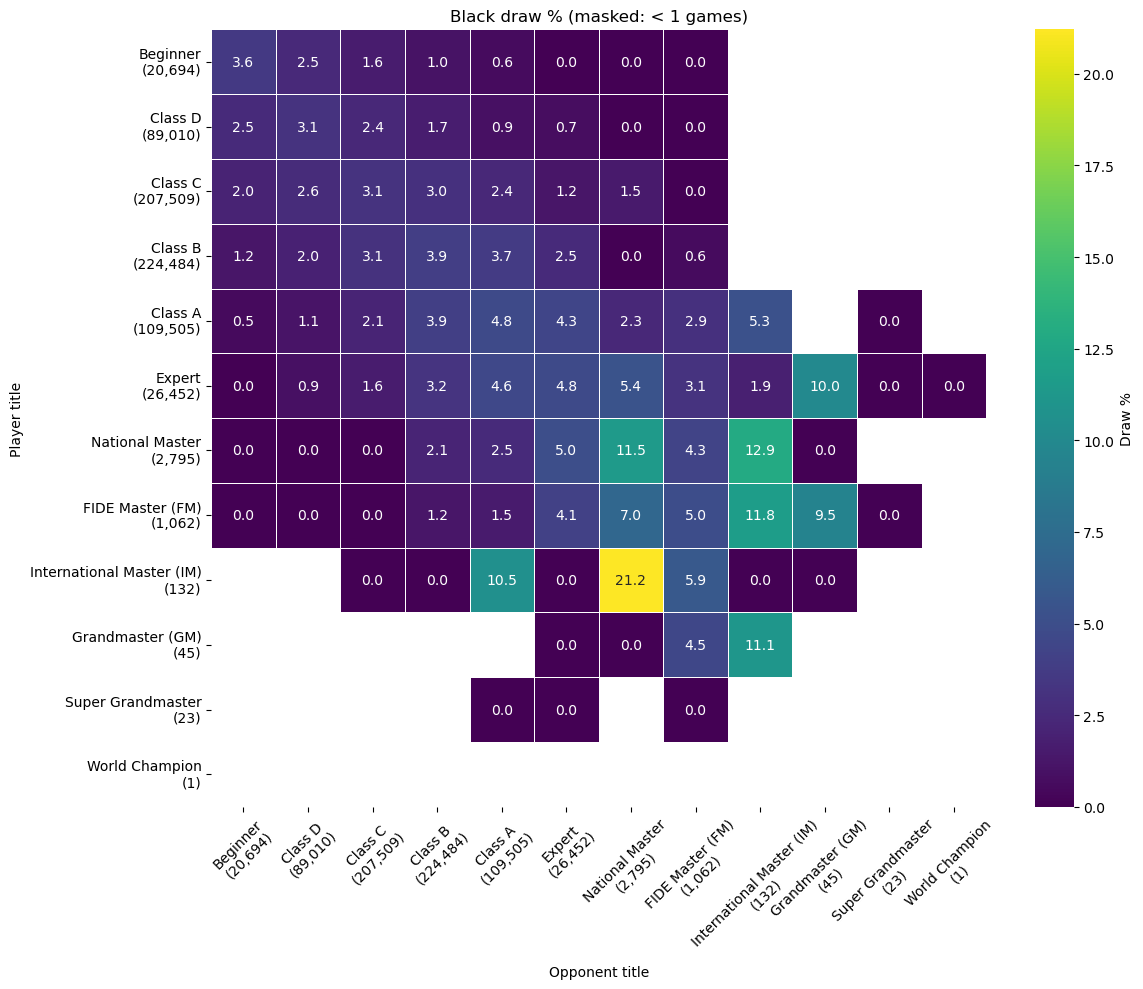

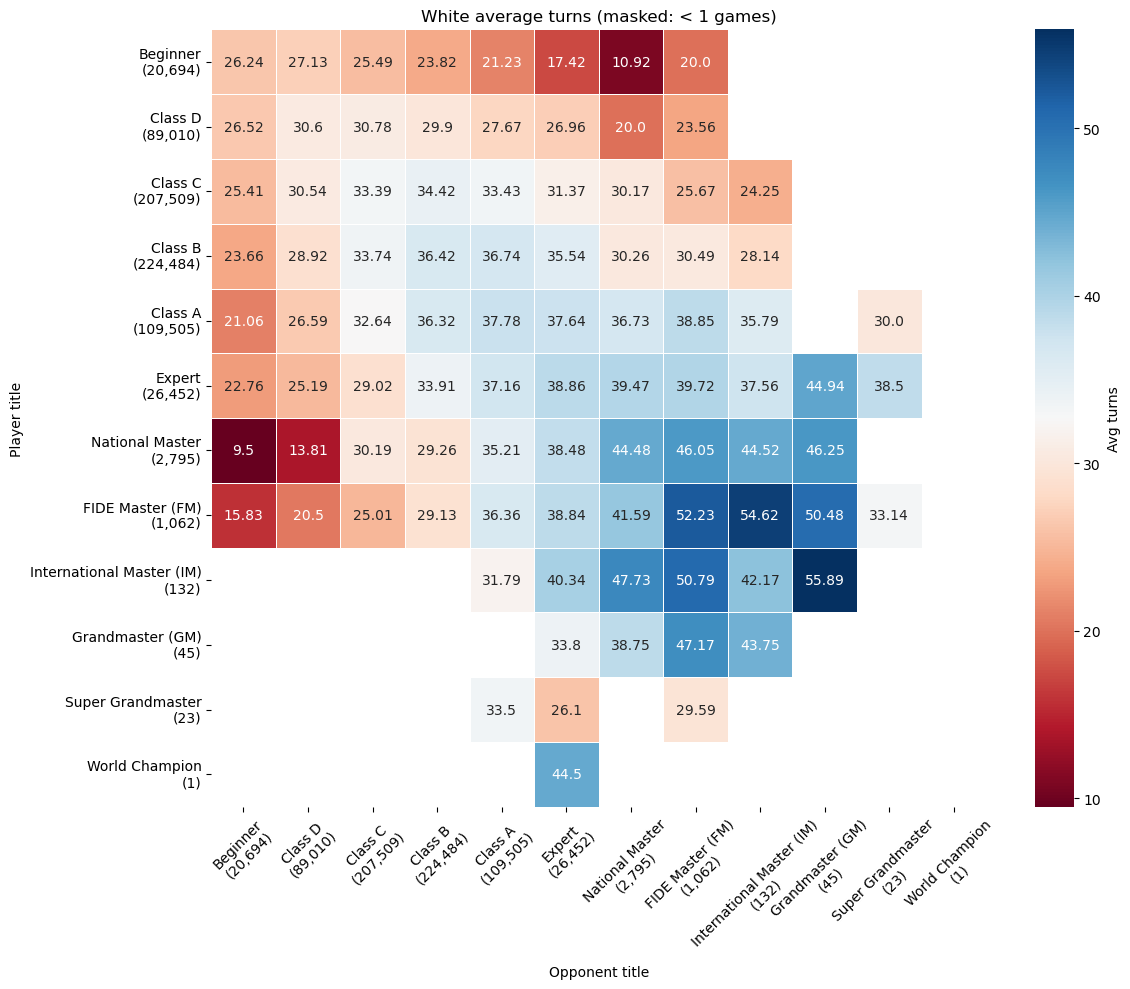

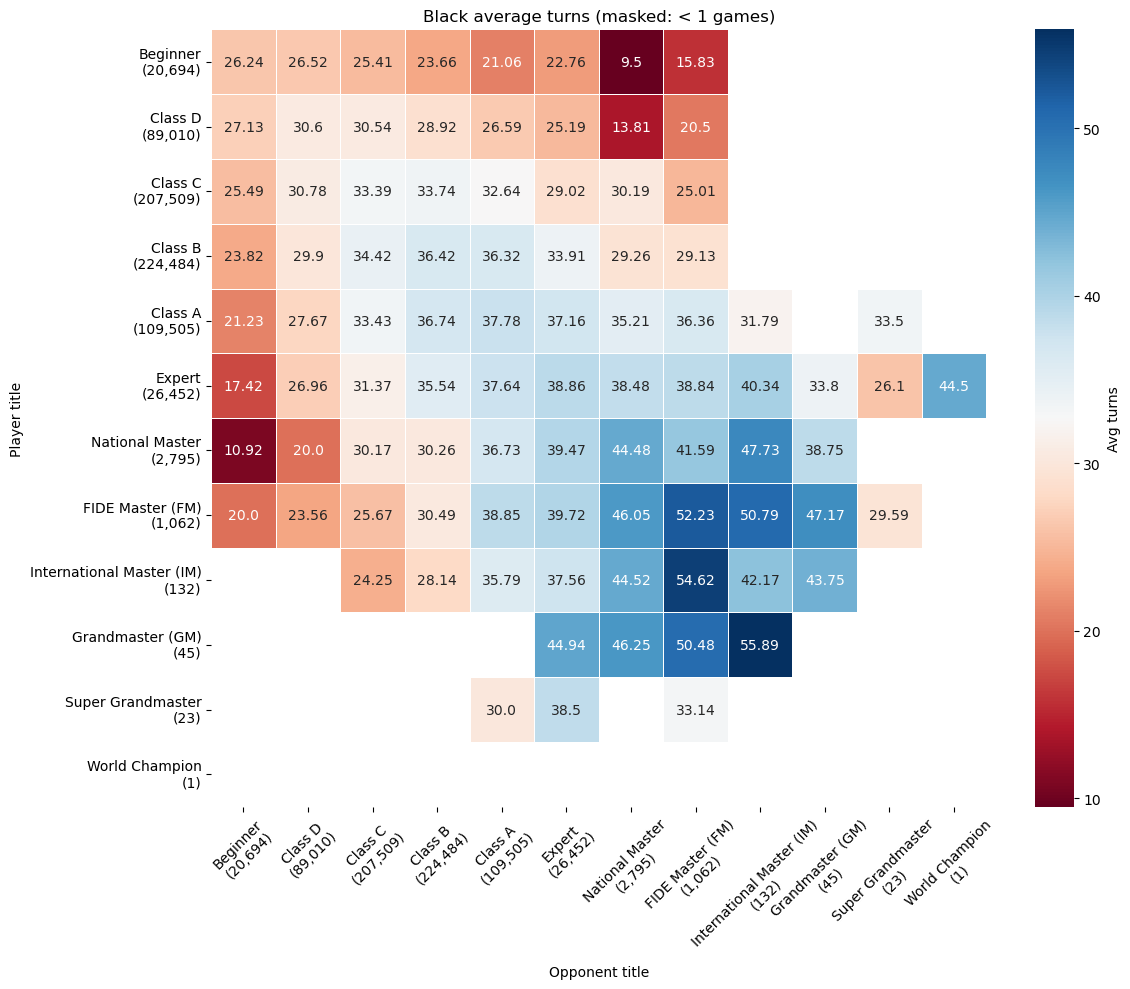

Accuracy: 0.48917244160891726

Classification report:
               precision    recall  f1-score   support

       black     0.6281    0.5182    0.5678     62171
        draw     0.0422    0.3614    0.0756      4397
       white     0.6933    0.4714    0.5612     69797

    accuracy                         0.4892    136365
   macro avg     0.4545    0.4503    0.4016    136365
weighted avg     0.6426    0.4892    0.5486    136365


Confusion matrix (rows=true, cols=pred):
 [[32214 16693 13264]
 [ 1518  1589  1290]
 [17558 19336 32903]]

Top feature importances:
 elo_diff        0.747366
WhiteElo_num    0.072145
BlackElo_num    0.064694
elo_mean        0.055158
ECO_A00         0.008996
ECO_OTHER       0.007332
ECO_A40         0.003161
ECO_C00         0.003062
ECO_B01         0.002965
ECO_B06         0.002909
ECO_C50         0.002732
ECO_B07         0.002704
ECO_D02         0.002506
ECO_D20         0.002448
ECO_C40         0.002205
ECO_A45         0.002031
ECO_A04         0.001987
ECO_C

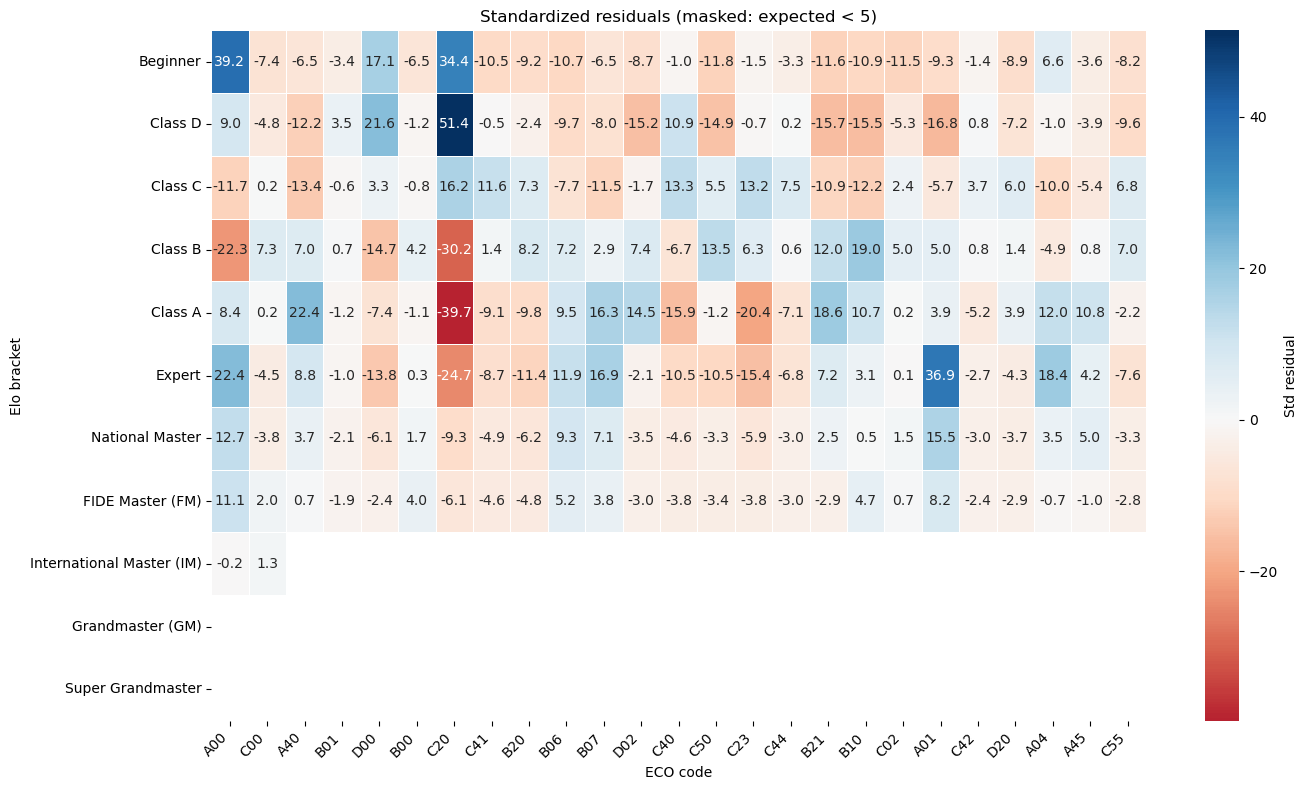


Drill-down: Class D × C20
Observed O = 7599, Expected E = 4247.0, std_resid = 51.43
Row total = 67626, Column total = 27478, N = 437534
pct_in_bracket = 11.24%, overall_pct = 6.28%, enrichment = 1.79


In [9]:
# 1) Load data
games_2014 = load_and_filter_games(FILE_JAN_2014)
print("Loaded Jan 2014 games:"); games_2014.info()

# 2) Enrich with numeric ELO and bracket labels (in-place)
enrich_with_elo_and_brackets(games_2014)

# 3) Build aggregated title-vs-title CSV (and capture DataFrame)
df_title_vs_title = build_title_vs_title_report_csv(games_2014, "./title_vs_title_report_jan2014.csv")

# 4) Visualizations (heatmaps)
plot_win_pct_heatmaps(df_title_vs_title, order=TITLE_ORDER, min_games=1)
plot_draw_pct_heatmaps(df_title_vs_title, order=TITLE_ORDER, min_games=1)
plot_avg_turns_heatmap(df_title_vs_title, order=TITLE_ORDER, min_games=1)

# 5) Train a decision tree classifier
clf, X_test, y_test, y_pred = train_and_evaluate_decision_tree(games_2014, eco_top_n=25, test_size=0.20, max_depth=10)
print(f"The resultant tree depth is: {clf.get_depth()}")

# 6) Chi-square / standardized residuals analysis
chi_results = chi_square_opening_vs_bracket(games_2014, bracket_col='White_bracket', eco_col='ECO', top_n=25, inspect_bracket='Class D', inspect_eco='C20', expected_thresh=5)
